nama: Callista Gianna Then

[LO1, LO2, LO3, & LO4 – 40 Points] Anda adalah seorang Data
Scientist di bidang botani. Anda mendapatkan tugas untuk
mengembangkan model Convolutional Neural Network (CNN) untuk
melakukan klasifikasi gambar berikut ini sesuai dataset anda:  
• 2A – Penyakit pada daun jagung
• 2B – Penyakit pada daun ceri
Download dataset yang telah disediakan dan buatlah model CNN
untuk melakukan multiclass classification dengan perincian task
berikut ini.
a.
[LO2 – 5 Points] Lakukan Exploratory Data Analysis
untuk memeriksa kondisi data yang anda miliki, seperti
aspect ratio & resolution. Lalu pisahkan data anda menjadi
train, validation, dan test dengan proporsi 70:15:15!
Lakukan pre-processing pada data anda.
b. [LO2, LO3, & LO4 – 5 Points] Buatlah sebuah model
CNN dengan arsitektur AlexNet secara manual (tidak
menggunakan pre-trained model dari Kerasa tau Pytorch)
seperti pada gambar di samping dan adaptasikan output
layer pada gambar sesuai dengan dataset anda. Model ini
akan disebut sebagai Baseline Model. Lakukan training
pada model anda dengan minimal 10 epoch dan analisis
hasilnya.
c.
[LO1, LO2, LO3, & LO4 – 10 Points] Modifikasi arsitektur AlexNet yang sudah dibuat. Anda bisa
menambahkan DropOut, Batch Normalization, dan sebagainya atau melakukan fine-tuning untuk
hyperparameter pada model ini. Anda juga bisa mengganti modelnya dengan arsitektur CNN lain
seperti DenseNet, EfficientNet, dan sebagainya. Jelaskan alasan modifikasi anda dan lakukan training
(minimal 10 epoch), serta analisis hasilnya.
d. [LO2, LO3, & LO4 – 15 Points] Lakukan evaluasi performa model anda pada data test dengan
menggunakan minimal 3 evaluation metrics. Analisis, jelaskan, dan simpulkan hasilnya. Lalu, berikan
saran untuk pengembangan lebih lanjut dari model anda.

##Load Libraries

In [3]:
#!pip install split-folders

In [42]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers


from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

#buat AlexNet
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout, BatchNormalization

from google.colab import drive
import splitfolders
from PIL import Image

import random

ko gregg, izin pake googledrive buat access datanya ya, aku butuh gpu yang ada di colab, tapi kalo upload folder ke sini, exceed max limitnya

file data.zip aku taro langsung di directory home page gdrive

zip file 2B --> 2C --> Cherry --> data

thats the folder i zipped and sent to gdrive home

### Load Data / files

In [9]:
drive.mount('/content/drive')

Mounted at /content/drive


In [12]:
os.listdir('/content/drive/MyDrive')

['Colab Notebooks', 'data.zip']

In [13]:
!unzip "/content/drive/MyDrive/data.zip" -d /content/

Archive:  /content/drive/MyDrive/data.zip
   creating: /content/data/
   creating: /content/data/Cherry brown_spot/
  inflating: /content/data/Cherry brown_spot/1.jpg  
  inflating: /content/data/Cherry brown_spot/10.jpg  
  inflating: /content/data/Cherry brown_spot/100.jpg  
  inflating: /content/data/Cherry brown_spot/101.jpg  
  inflating: /content/data/Cherry brown_spot/102.jpg  
  inflating: /content/data/Cherry brown_spot/103.jpg  
  inflating: /content/data/Cherry brown_spot/104.jpg  
  inflating: /content/data/Cherry brown_spot/105.jpg  
  inflating: /content/data/Cherry brown_spot/106.jpg  
  inflating: /content/data/Cherry brown_spot/107.jpg  
  inflating: /content/data/Cherry brown_spot/108.jpg  
  inflating: /content/data/Cherry brown_spot/109.jpg  
  inflating: /content/data/Cherry brown_spot/11.jpg  
  inflating: /content/data/Cherry brown_spot/110.jpg  
  inflating: /content/data/Cherry brown_spot/111.jpg  
  inflating: /content/data/Cherry brown_spot/112.jpg  
  inflat

In [14]:
print(os.listdir('/content'))

['.config', 'data', 'drive', 'sample_data']


In [15]:
print(os.listdir('/content/data'))

['Cherry Leaf Scorch', 'Cherry Normal leaf', 'Cherry_shot hole disease', 'Cherry purple leaf spot', 'Cherry brown_spot']


In [16]:
for folder in os.listdir('/content/data'):
    folder_path = os.path.join('/content/data', folder)
    print(folder, ":", len(os.listdir(folder_path)))

Cherry Leaf Scorch : 1101
Cherry Normal leaf : 500
Cherry_shot hole disease : 440
Cherry purple leaf spot : 987
Cherry brown_spot : 614


In [17]:
data_dir = '/content/data'

### EDA

aspect ratio & resolution

In [19]:
classes = os.listdir(data_dir)
print("Classes:", classes)
print("N classes:", len(classes))

Classes: ['Cherry Leaf Scorch', 'Cherry Normal leaf', 'Cherry_shot hole disease', 'Cherry purple leaf spot', 'Cherry brown_spot']
N classes: 5


In [20]:
class_counts = {}

for folder in classes:
    folder_path = os.path.join(data_dir, folder)
    class_counts[folder] = len(os.listdir(folder_path))

df_counts = pd.DataFrame.from_dict(class_counts, orient='index', columns=['count'])
print(df_counts)

                          count
Cherry Leaf Scorch         1101
Cherry Normal leaf          500
Cherry_shot hole disease    440
Cherry purple leaf spot     987
Cherry brown_spot           614


checking general class distribution, leaf scorch is very highly represented

1101/440

the largest class is 2.5x tyhe size of the smaller class

theres moderate class imbalance. The model may develop slight bias toward dominant classes, but it is still manageable. however the model will struggle to generalize across minority classes.


--> data augmentation



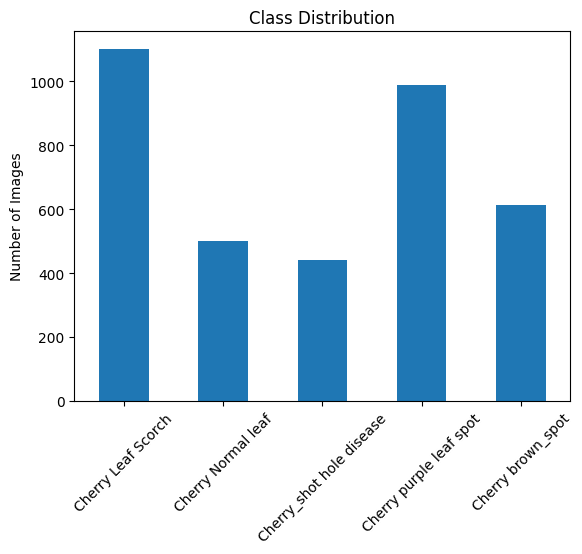

In [21]:
df_counts.plot(kind='bar', legend=False)
plt.title('Class Distribution')
plt.ylabel('Number of Images')
plt.xticks(rotation=45)
plt.show()

for aspect ratio down below

In [22]:
widths = []
heights = []

for folder in classes:
    folder_path = os.path.join(data_dir, folder)

    for file in os.listdir(folder_path)[:100]:
        img = Image.open(os.path.join(folder_path, file))
        w, h = img.size
        widths.append(w)
        heights.append(h)

print("Sample widths:", widths[:10])
print("Sample heights:", heights[:10])

Sample widths: [800, 800, 800, 800, 800, 800, 800, 800, 800, 800]
Sample heights: [1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000]


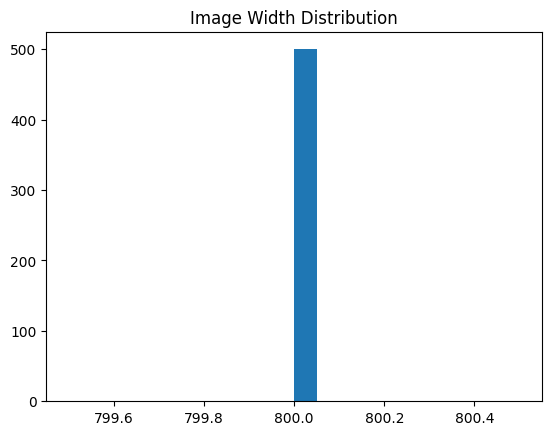

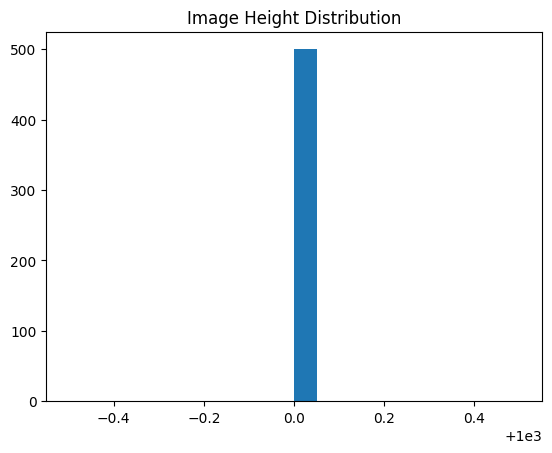

In [23]:
plt.hist(widths, bins=20)
plt.title("Image Width Distribution")
plt.show()

plt.hist(heights, bins=20)
plt.title("Image Height Distribution")
plt.show()

all images is safe to assume to have

width x height

800 x 1000

##### see some sample imahges from each class

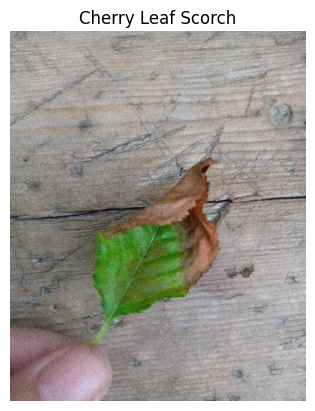

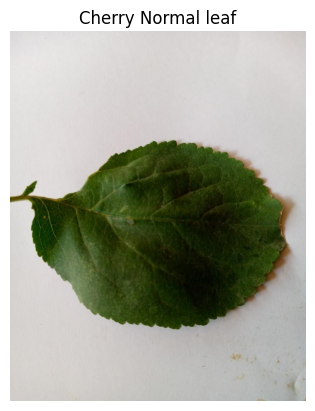

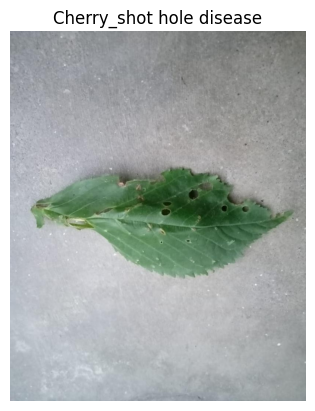

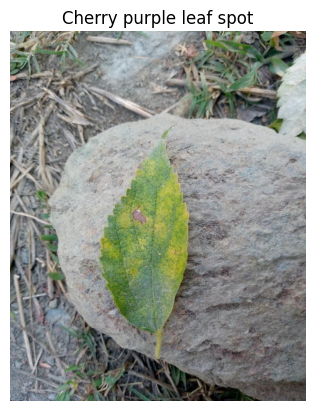

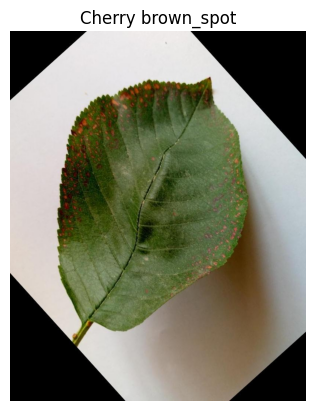

In [24]:
for folder in classes:
    folder_path = os.path.join(data_dir, folder)
    img_path = os.path.join(folder_path, os.listdir(folder_path)[0])

    img = Image.open(img_path)
    plt.imshow(img)
    plt.title(folder)
    plt.axis('off')
    plt.show()

there are visible differences in leaf conditions and orientations --> supports image based classification

### Splitting 70:15:15

In [25]:
splitfolders.ratio(
    '/content/data',
    output='/content/data_split',
    seed=42,
    ratio=(0.7, 0.15, 0.15)
)

Copying files: 3642 files [00:07, 491.19 files/s]


In [26]:
for split in ['train', 'val', 'test']:
    print(f"\n{split.upper()}:")
    split_path = f'/content/data_split/{split}'

    for cls in os.listdir(split_path):
        count = len(os.listdir(os.path.join(split_path, cls)))
        print(f"{cls}: {count}")


TRAIN:
Cherry Leaf Scorch: 770
Cherry Normal leaf: 350
Cherry_shot hole disease: 308
Cherry purple leaf spot: 690
Cherry brown_spot: 429

VAL:
Cherry Leaf Scorch: 165
Cherry Normal leaf: 75
Cherry_shot hole disease: 66
Cherry purple leaf spot: 148
Cherry brown_spot: 92

TEST:
Cherry Leaf Scorch: 166
Cherry Normal leaf: 75
Cherry_shot hole disease: 66
Cherry purple leaf spot: 149
Cherry brown_spot: 93


### Pre-processing

augmentation why?

uneven class between cherry leaves

model is likely to overfit dominant classes

augmentation increases data diversity and helps the model generalize better
--> adjust the orientation of the same image

In [28]:
train_gen = ImageDataGenerator(

    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,

    fill_mode='nearest'
)

#augmentation only for train data

In [29]:
val_gen = ImageDataGenerator(rescale=1./255)
test_gen = ImageDataGenerator(rescale=1./255)

#no augmentation for validation and test data

In [30]:
img_size = (224, 224)

train_data = train_gen.flow_from_directory(
    '/content/data_split/train',
    target_size=img_size,
    batch_size=32,
    class_mode='categorical'
)

val_data = val_gen.flow_from_directory(
    '/content/data_split/val',
    target_size=img_size,
    batch_size=32,
    class_mode='categorical'
)

test_data = test_gen.flow_from_directory(
    '/content/data_split/test',
    target_size=img_size,
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 2547 images belonging to 5 classes.
Found 546 images belonging to 5 classes.
Found 549 images belonging to 5 classes.


In [31]:
print(train_data.class_indices)

{'Cherry Leaf Scorch': 0, 'Cherry Normal leaf': 1, 'Cherry brown_spot': 2, 'Cherry purple leaf spot': 3, 'Cherry_shot hole disease': 4}


### ANN with AlexNet

AlexNet --> uses Conv + ReLU and pooling

layers are fully connected at the end

- Input max is (224x224x3)
- Conv1 → ReLU → MaxPool
convoluted layer 1
- Conv2 → ReLU → MaxPool
- Conv3 → ReLU
- Conv4 → ReLU
- Conv5 → ReLU → MaxPool
- Flatten

1. Conv Layers
- extract features --> edges, textures, disease patterns
- moree deep, more complex pattern

2. ReLU Activation
- helps model learn complex non-linear relationsip

3. MaxPooling
- help prevent overfitting by reducing spatial size

4. Flatten
- feature maps → 1D vector

#### Baseline AlexNet

In [34]:
model = Sequential()

#input and conv
model.add(Conv2D(96, (11,11), strides=4, activation='relu', input_shape=(224,224,3)))
model.add(MaxPooling2D(pool_size=(3,3), strides=2))

#conv
model.add(Conv2D(256, (5,5), padding='same', activation='relu'))
model.add(MaxPooling2D(pool_size=(3,3), strides=2))

#conv 3
model.add(Conv2D(384, (3,3), padding='same', activation='relu'))

#conv4
model.add(Conv2D(384, (3,3), padding='same', activation='relu'))

#conv 5
model.add(Conv2D(256, (3,3), padding='same', activation='relu'))
model.add(MaxPooling2D(pool_size=(3,3), strides=2))

model.add(Flatten()) #flatten


model.add(Dense(4096, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(4096, activation='relu'))
model.add(Dropout(0.5))

#output for 5 classes
model.add(Dense(5, activation='softmax'))


model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 54, 54, 96)     │        34,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 26, 26, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 26, 26, 256)    │       614,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 384)    │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 12, 12, 384)    │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 256)    │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 5, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4096)           │    26,218,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │        20,485 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,767,493 (178.40 MB)

 Trainable params: 46,767,493 (178.40 MB)

 Non-trainable params: 0 (0.00 B)

In [35]:
Dense(5, activation='softmax')

<Dense name=dense_3, built=False>

In [36]:
history_base = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 557s 7s/step - accuracy: 0.3534 - loss: 1.6926 - val_accuracy: 0.5293 - val_loss: 1.1995
Epoch 2/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 539s 7s/step - accuracy: 0.4817 - loss: 1.2734 - val_accuracy: 0.5531 - val_loss: 1.1942
Epoch 3/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 550s 7s/step - accuracy: 0.5124 - loss: 1.1939 - val_accuracy: 0.5842 - val_loss: 1.0560
Epoch 4/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 548s 7s/step - accuracy: 0.5418 - loss: 1.1237 - val_accuracy: 0.5824 - val_loss: 1.0292
Epoch 5/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 566s 7s/step - accuracy: 0.5524 - loss: 1.0849 - val_accuracy: 0.6154 - val_loss: 0.9502
Epoch 6/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 531s 7s/step - accuracy: 0.5909 - loss: 1.0287 - val_accuracy: 0.5458 - val_loss: 1.1369
Epoch 7/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 532s 7s/step - accuracy: 0.5925 - loss: 1.0087 - val_accuracy: 0.6465 - val_loss: 0.8920
Epoch 8/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 527s 7s/step - accuracy: 0.6262 - loss: 0.9560 - val_accuracy: 0.5531 - v

Epoch 10/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 550s 7s/step - accuracy: 0.6368 - loss: 0.9104 - val_accuracy: 0.6227 - val_loss: 0.9835



by the time epoch reaches the 10th

the AlexNet baseline model has

accuracy: 0.636

loss: 0.9104

val_accuracy: 0.623

val_loss: 0.94


1. loss is still relatively high when accuracy is already > 50%
- this implies that the model is still able to extract meanungful features but it performs moderately

2. the gap between training and validation accuracy is relatively small
- no significat overfitting is happening

3. the values between validation loss and accuracy is similar to model accuracy and loss
- in a way, the model generalises unseen data passably (its still baseline)

but loss may still be high because alexnet is built to run on very large datasets. theres an imbalance between model size and dataset size

4. both train and validation loss is still high --> model is not confident in its prediction
- the probability for the correct class is not dominant enough
- the model is giving the correct class a high probability

#### AlexNet modified

In [44]:
model_mod = Sequential()

#BLOCKS 5
model_mod.add(Conv2D(96, (11,11), strides=4, activation='relu', input_shape=(224,224,3)))
model_mod.add(BatchNormalization())
model_mod.add(MaxPooling2D(pool_size=(3,3), strides=2))


model_mod.add(Conv2D(256, (5,5), padding='same', activation='relu'))
model_mod.add(BatchNormalization())
model_mod.add(MaxPooling2D(pool_size=(3,3), strides=2))

model_mod.add(Conv2D(384, (3,3), padding='same', activation='relu'))
model_mod.add(BatchNormalization())


model_mod.add(Conv2D(384, (3,3), padding='same', activation='relu'))
model_mod.add(BatchNormalization())

model_mod.add(Conv2D(256, (3,3), padding='same', activation='relu'))
model_mod.add(BatchNormalization())
model_mod.add(MaxPooling2D(pool_size=(3,3), strides=2))


model_mod.add(Flatten()) #flatten

# Modified Fully Connected Layers
model_mod.add(Dense(1024, activation='relu'))
model_mod.add(Dropout(0.5))
model_mod.add(Dense(512, activation='relu'))
model_mod.add(Dropout(0.5))


#for output
model_mod.add(Dense(5, activation='softmax'))

#compile
model_mod.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [45]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history_mod = model_mod.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    callbacks=[early_stop]
)

Epoch 1/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 505s 6s/step - accuracy: 0.4280 - loss: 4.2551 - val_accuracy: 0.2198 - val_loss: 6.6355
Epoch 2/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 511s 6s/step - accuracy: 0.6066 - loss: 1.3398 - val_accuracy: 0.4597 - val_loss: 1.3808
Epoch 3/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 498s 6s/step - accuracy: 0.6584 - loss: 0.9961 - val_accuracy: 0.6044 - val_loss: 1.1289
Epoch 4/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 495s 6s/step - accuracy: 0.7020 - loss: 0.9037 - val_accuracy: 0.3022 - val_loss: 2.0463
Epoch 5/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 508s 6s/step - accuracy: 0.6957 - loss: 0.8941 - val_accuracy: 0.6813 - val_loss: 0.7735
Epoch 6/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 495s 6s/step - accuracy: 0.7236 - loss: 0.7349 - val_accuracy: 0.5788 - val_loss: 1.1076
Epoch 7/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 498s 6s/step - accuracy: 0.7672 - loss: 0.6279 - val_accuracy: 0.4194 - val_loss: 2.4315
Epoch 8/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 494s 6s/step - accuracy: 0.7742 - loss: 0.6030 - val_accuracy: 0.5568 - v

in epoch 4
Train Accuracy : 70.20%
Train Loss     : 0.9037

Val Accuracy   : 30.22%
Val Loss       : 2.0463


but in epoch 5
Train Accuracy : 69.57%
Train Loss     : 0.8941

Val Accuracy   : 68.13%
Val Loss       : 0.7735


between epoch 4 and epoch 5, validation accuracy increased and validation loss decreased

at epoch 5, the model sucessfully stabilized and started to generalise better

training accuracy dropped --> this can be due to batch normalisation which regulizes the layers --> they make feature layers smaller but will make training more difficult as they prevent the model from memorizing


but then at epoch 6

Train Acc : 72.36%  inc
Val Acc   : 57.88%  dec
Val Loss  : 1.1076  inc

the training accuracy increased, validation accuracy decreased significantly, validation loss increased

--> this is a sign of early overfitting

--> the model is starting to fit the training data better, but performance on unseen data is worsening

batch normalisattion and the learning rate of Adam which may be a little agressive on the dataset --> cause oscillation on the model's performance


best performance

--> epoch 5

highest validation accuracy

lowest validation loss

what changed from the baseline to the modified


MODIFIED


- for each convolutional layer theres batch normalisation
- dropout is kept on each fully connected layer

since the AlexNet was originally designed for big datasets --> like ImageNet

but our dataset has around 3600 images and 5 classes --> so the model may have too much parameters --> risk of overfitting


Batch Normalisation
--> normalize feature distribution and reduce internal covariance shift
--> will lead to faster convergence and better generalisation


Reduction of Layers
--> original: 4096 neurons
--> modified: 1024 to 512


Dropout
- will randomly disable neurons when training
--> helps overfitting because of large feature layers


OPtimizer: Adam
epoch >= 10 (10 because my laptop is taking long time)



### Evaluation Metrics

In [46]:
y_pred_base = model.predict(test_data)
y_pred_mod  = model_mod.predict(test_data)

18/18 ━━━━━━━━━━━━━━━━━━━━ 42s 2s/step
18/18 ━━━━━━━━━━━━━━━━━━━━ 26s 1s/step


In [47]:
y_pred_baseclass = np.argmax(y_pred_base, axis=1)
y_pred_modclass  = np.argmax(y_pred_mod, axis=1)

y_true = test_data.classes

In [48]:
#for base model

acc_base = accuracy_score(y_true, y_pred_baseclass)
prec_base = precision_score(y_true, y_pred_baseclass, average='weighted')
rec_base  = recall_score(y_true, y_pred_baseclass, average='weighted')
f1_base   = f1_score(y_true, y_pred_baseclass, average='weighted')
acc_mod  = accuracy_score(y_true, y_pred_baseclass)

print("BASELINE\n")
print("Accuracy:", acc_base)
print("Precision:", prec_base)
print("Recall   :", rec_base)
print("F1 Score :", f1_base)


acc_mod  = accuracy_score(y_true, y_pred_modclass)
prec_mod = precision_score(y_true, y_pred_modclass, average='weighted')
rec_mod  = recall_score(y_true, y_pred_modclass, average='weighted')
f1_mod   = f1_score(y_true, y_pred_modclass, average='weighted')

print ("MODIFIED\n")
print("Accuracy:", acc_base)
print("Precision:", prec_base)
print("Recall   :", rec_base)
print("F1 Score :", f1_base)


BASELINE

Accuracy: 0.6102003642987249
Precision: 0.6011246025005539
Recall   : 0.6102003642987249
F1 Score : 0.5890371660666837
MODIFIED

Accuracy: 0.6102003642987249
Precision: 0.6011246025005539
Recall   : 0.6102003642987249
F1 Score : 0.5890371660666837


In [50]:
#confusion metrics

m_base = confusion_matrix(y_true, y_pred_baseclass)
m_mod  = confusion_matrix(y_true, y_pred_modclass)

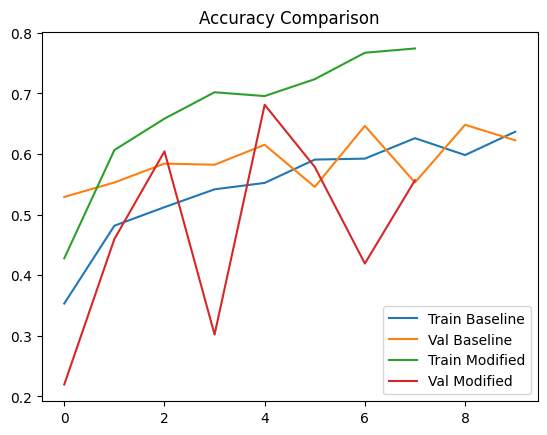

In [51]:
#TRAINING CURVE
# Accuracy
plt.plot(history_base.history['accuracy'], label='Train Baseline')
plt.plot(history_base.history['val_accuracy'], label='Val Baseline')

plt.plot(history_mod.history['accuracy'], label='Train Modified')
plt.plot(history_mod.history['val_accuracy'], label='Val Modified')

plt.title('Accuracy Comparison')
plt.legend()
plt.show()

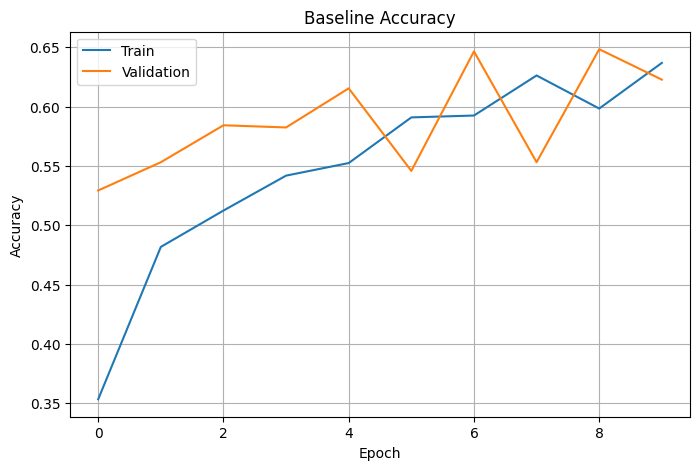

In [53]:
plt.figure(figsize=(8,5))

plt.plot(history_base.history['accuracy'], label='Train')
plt.plot(history_base.history['val_accuracy'], label='Validation')
plt.title('Baseline Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()

plt.show()

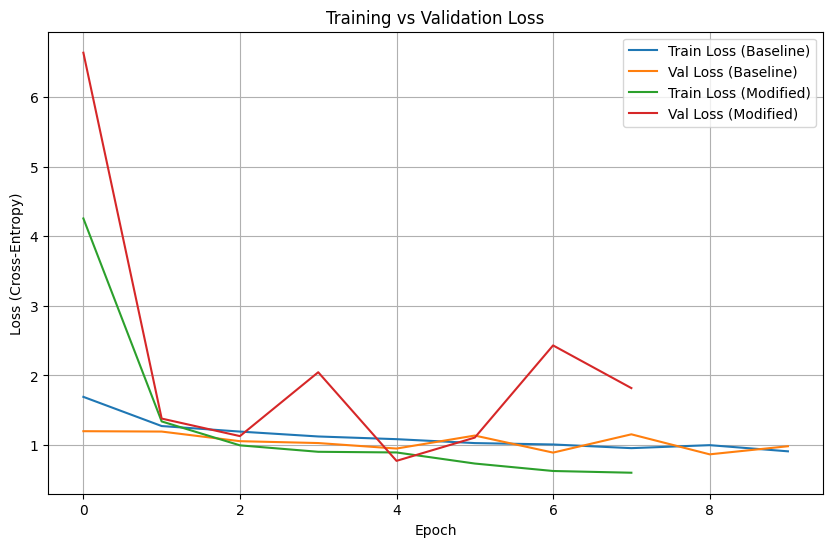

In [54]:
plt.figure(figsize=(10,6))

# for baseline
plt.plot(history_base.history['loss'], label='Train Loss (Baseline)')
plt.plot(history_base.history['val_loss'], label='Val Loss (Baseline)')

#for modified
plt.plot(history_mod.history['loss'], label='Train Loss (Modified)')
plt.plot(history_mod.history['val_loss'], label='Val Loss (Modified)')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (Cross-Entropy)')
plt.legend()
plt.grid()

plt.show()

training loss is the blue graph --> gradually decreases from 1.7 to 0.95

this can indicate a smooth learning


validation loss is orange --> slightly decreased and then fluctuates around 0.9 to 1.1

the baseline model is relatively stable with no large fluctuations over each epoch

but it plateaus early which may indicate a limited learning capacity or under optimisation


modified training loss is the green line that dips sharply at 4.2 to 0.6 which is lower than the baseline model --> the modified model fits training data better

validation loss --> was really high then drops sharply and fluctuates heavily at 3 and 6

but validation loss dips mostly at epoch 4 --> best point

modified model learns faster but it is unstable --> batch normalisation and dropout with some signs of over fitting